In [1]:
# Defining the transformation for the dataset

from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.Grayscale(num_output_channels=3),  # 1 → 3 channels
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std =[0.229, 0.224, 0.225])
])

In [2]:
# Download the PathMNIST dataset directly
from medmnist import PathMNIST

# Download train, validation, and test splits
train_dataset = PathMNIST(split="train", download=True, transform = transform)
val_dataset = PathMNIST(split="val", download=True, transform = transform)
test_dataset = PathMNIST(split="test", download=True, transform = transform)

Using downloaded and verified file: /home/yousifcreates/.medmnist/pathmnist.npz
Using downloaded and verified file: /home/yousifcreates/.medmnist/pathmnist.npz
Using downloaded and verified file: /home/yousifcreates/.medmnist/pathmnist.npz


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.59380084..2.2739873].


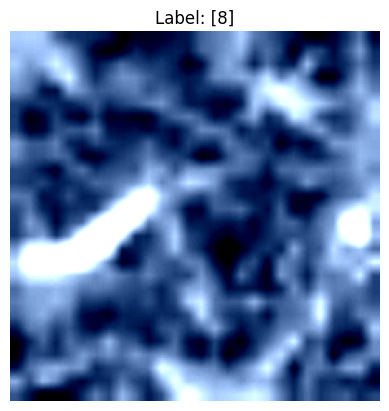

In [3]:
img, label = train_dataset[5]

import matplotlib.pyplot as plt

# Display the image and label
plt.imshow(img.permute(1, 2, 0))  # Permute to (H, W, C) for plotting
plt.title(f"Label: {label}")
plt.axis('off')
plt.show()

In [4]:
from medmnist import INFO

info = INFO['pathmnist']
info_dict = info['label']

# Convert the label dictonary to a list of class names
class_names = [info_dict[key] for key in sorted(info_dict.keys())]

# Print the Indexes and their corresponding class names on new line
for index, class_name in enumerate(class_names):
    print(f"{index}: {class_name}")

0: adipose
1: background
2: debris
3: lymphocytes
4: mucus
5: smooth muscle
6: normal colon mucosa
7: cancer-associated stroma
8: colorectal adenocarcinoma epithelium


In [5]:
# Checking the type of image and label
img, label = train_dataset[0]
print(f"Image type: {type(img)}, Image shape: {img.size}")
print(f"Label type: {type(label)}, Label value: {label}")

Image type: <class 'torch.Tensor'>, Image shape: <built-in method size of Tensor object at 0x73b591e8ae30>
Label type: <class 'numpy.ndarray'>, Label value: [0]


In [6]:
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim

# Set random seeds for reproducibility
torch.manual_seed(42)

In [7]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [8]:
train_dataloader = DataLoader(train_dataset, batch_size = 64, shuffle = True, pin_memory = True)
val_dataloader = DataLoader(val_dataset, batch_size = 64, shuffle = False, pin_memory = True)
test_dataloader = DataLoader(test_dataset, batch_size = 64, shuffle = False, pin_memory = True)

In [9]:
# fetch the pretrained model

import torchvision.models as models

vgg16 = models.vgg16(pretrained=True)

/home/yousifcreates/anaconda3/envs/obj-dect/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/yousifcreates/anaconda3/envs/obj-dect/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [10]:
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [11]:
import torch.nn as nn
import torchvision.models as models

vgg16 = models.vgg16(pretrained=True)

# Freeze feature extractor
for param in vgg16.features.parameters():
    param.requires_grad = False

# Replace classifier output layer
vgg16.classifier[6] = nn.Linear(4096, 9)  # 9 classes

vgg16 = vgg16.to(device)

In [12]:
learning_rate = 0.0001
epochs = 50

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(vgg16.classifier.parameters(), lr = learning_rate)

In [14]:
# Training loop

for epoch in range(epochs):
    
    total_epoch_loss = 0
    
    for batch, (X, y) in enumerate(train_dataloader):
        
        y = y.squeeze().long()
        
        X, y = X.to(device), y.to(device)
        
        # Forward Pass
        outputs = vgg16(X)
        
        # Calculate Loss
        
        loss = criterion(outputs, y)
        
        # Zero Gradients
        
        optimizer.zero_grad()
        
        # Backward Pass
        
        loss.backward()
        
        # Update Weights
        optimizer.step()
        
        total_epoch_loss = total_epoch_loss + loss.item()
        break
    
    print(f"Epoch: {epoch} | Loss: {total_epoch_loss/len(train_dataloader)}")

Epoch: 0 | Loss: 0.0015956155781044381
Epoch: 1 | Loss: 0.0015670541507094653
Epoch: 2 | Loss: 0.0014389554235896237
Epoch: 3 | Loss: 0.0013703512823488497
Epoch: 4 | Loss: 0.0012585964284217688
Epoch: 5 | Loss: 0.0012457760497027453
Epoch: 6 | Loss: 0.0011591955373366843
Epoch: 7 | Loss: 0.0011219758045275159
Epoch: 8 | Loss: 0.0010168370238075716
Epoch: 9 | Loss: 0.0009191150604280581
Epoch: 10 | Loss: 0.0009325630883418167
Epoch: 11 | Loss: 0.0010258994715893277
Epoch: 12 | Loss: 0.000886601002062138
Epoch: 13 | Loss: 0.0009729480946750275
Epoch: 14 | Loss: 0.0007294444387147168
Epoch: 15 | Loss: 0.0007493951766306234
Epoch: 16 | Loss: 0.0006482685044376073
Epoch: 17 | Loss: 0.0007266596690423962
Epoch: 18 | Loss: 0.0005936407839565643
Epoch: 19 | Loss: 0.0004740207857838233
Epoch: 20 | Loss: 0.0006783074661612765
Epoch: 21 | Loss: 0.0007850418890632461
Epoch: 22 | Loss: 0.00070081370556363
Epoch: 23 | Loss: 0.0007025353774671954
Epoch: 24 | Loss: 0.0006177251696501883
Epoch: 25 | L

In [15]:
vgg16.eval()

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [16]:
# evaluation on test data
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in test_dataloader:

    batch_labels = batch_labels.squeeze().long()
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = vgg16(batch_features)

    _, predicted = torch.max(outputs.data, 1)

    total += batch_labels.size(0)
    correct += (predicted == batch_labels).sum().item()

print(correct/total)

0.8047353760445682


In [ ]:
# evaluation on train data
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in train_dataloader:

    batch_labels = batch_labels.squeeze().long()
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = vgg16(batch_features)

    _, predicted = torch.max(outputs.data, 1)

    total += batch_labels.size(0)
    correct += (predicted == batch_labels).sum().item()

print(correct/total)

0.7553335703809059


In [18]:
# evaluation on valdidation data
total = 0
correct = 0

with torch.no_grad():

  for batch_features, batch_labels in val_dataloader:

    batch_labels = batch_labels.squeeze().long()
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = vgg16(batch_features)

    _, predicted = torch.max(outputs.data, 1)

    total += batch_labels.size(0)
    correct += (predicted == batch_labels).sum().item()

print(correct/total)

0.7556977209116353
